<a href="https://colab.research.google.com/github/bysischpok/ML/blob/main/lab6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа 6. Чёрный ящик и трансферируемость атак: transfer-based, score-based, decision-based методы

**Курс:** Машинное обучение. Безопасность ИИ-систем

**По материалам лекции 5**


**Среда:** Python, PyTorch, torchvision


## Цель работы
Закрепить методы построения adversarial-примеров в условиях ограниченного доступа к целевой модели и научиться сравнивать transfer-based, score-based и decision-based атаки по успешности, числу запросов и величине вносимого искажения.

## Результаты обучения
После выполнения работы вы должны уметь:
- обучать суррогатную модель через запросы к оракулу и переносить на неё белоящичную атаку (transfer-based);
- реализовывать оценку градиента через запросы confidence-баллов методом конечных разностей (ZOO) и методом случайной выборки (NES);
- реализовывать decision-based атаку (Boundary Attack), работающую только с итоговой меткой класса;
- сравнивать три класса чёрно-ящичных атак по критерию «качество атаки / стоимость запросов» и обосновывать выбор метода под конкретный сценарий доступа к API.

## Как пользоваться этим ноутбуком
- Ячейки с `# TODO` необходимо заполнить самостоятельно.
- Ячейки с текстом **"Вопрос для отчёта"** требуют письменного ответа в markdown-ячейке ниже.
- Перед сдачей: Kernel → Restart & Run All, ноутбук должен выполняться от начала до конца без ошибок.
- Все атаки в этой работе взаимодействуют с целевой моделью только через специальный объект-оракул — прямой доступ к её параметрам и градиентам запрещён по условию задания (это имитирует реальный чёрный ящик).


## 0. Подготовка окружения

In [1]:
# TODO: импортируйте необходимые библиотеки
# Подсказка: numpy, matplotlib, torch, torch.nn, torch.nn.functional,
# torchvision (datasets, transforms), torch.utils.data.DataLoader, pandas, time

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import pandas as pd
import time

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

device = torch.device("cpu")

## Часть I. Целевая модель и оракул

**Задание:** загрузите MNIST, обучите CNN-классификатор (2 свёрточных слоя + полносвязный классификатор) — эта модель будет играть роль "чёрного ящика". Затем реализуйте класс-обёртку `QueryCounter`, через который ВСЕ последующие атаки должны обращаться к модели — прямой вызов `target_model(x)` в атаках запрещён, чтобы корректно считать число запросов.

In [2]:
# TODO: загрузите MNIST через torchvision.datasets, создайте train_loader и test_loader
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)


100%|██████████| 9.91M/9.91M [00:00<00:00, 41.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.11MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.1MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.5MB/s]


In [3]:
import torch.nn as nn
import torch.nn.functional as F

# TODO: реализуйте класс TargetCNN (2 свёрточных слоя, max pooling, полносвязный классификатор)
class TargetCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32 * 7 * 7, 64)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

In [4]:
# TODO: обучите target_model на train_loader (2-3 эпохи)
target_model = TargetCNN().to(device)
opt = torch.optim.Adam(target_model.parameters(), lr=1e-3)
crit = nn.CrossEntropyLoss()

for epoch in range(2):
    target_model.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        opt.zero_grad()
        loss = crit(target_model(images), labels)
        loss.backward()
        opt.step()

In [5]:
# TODO: оцените clean accuracy на тестовой выборке
target_model.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        preds = target_model(images).argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
clean_accuracy = correct / total
print(f"Clean accuracy: {clean_accuracy:.4f}")

Clean accuracy: 0.9817


**Задание:** реализуйте класс `QueryCounter`, который считает число обращений к модели и предоставляет три уровня доступа:
- `logits(x)` — полные логиты (используется только для white-box эталона в Части V, НЕ для чёрно-ящичных атак);
- `probs(x)` — вероятности классов (softmax) — доступ уровня score-based;
- `label(x)` — только индекс предсказанного класса — доступ уровня decision-based.

Каждый вызов любого из трёх методов должен увеличивать счётчик `n_queries` на размер батча.

In [6]:
# TODO: реализуйте класс QueryCounter
class QueryCounter:
    def __init__(self, model):
        self.model = model
        self.n_queries = 0

    def reset(self):
        self.n_queries = 0

    def logits(self, x):
        self.n_queries += x.size(0)
        with torch.no_grad():
            return self.model(x)

    def probs(self, x):
        return F.softmax(self.logits(x), dim=1)

    def label(self, x):
        return self.logits(x).argmax(dim=1)

oracle = QueryCounter(target_model)


## Часть II. Transfer-based атака

### 2.1. Обучение суррогатной модели через оракул

**Задание:** реализуйте суррогатную модель с архитектурой, отличной от целевой (например, полносвязная сеть вместо CNN), и обучите её по схеме Papernot et al.:

1. Соберите небольшой начальный набор данных (например, 20 примеров на класс) без использования меток из исходного датасета — размечайте их исключительно через `oracle.label(x)`.
2. Обучите суррогат на текущем наборе.
3. Постройте аугментацию данных по знаку якобиана суррогатной модели:

$ S_{\rho+1} = \left\{ \tilde{x} + \lambda \cdot \text{sign}\left(J_F[\tilde{O}(\tilde{x})]\right) : \tilde{x} \in S_\rho \right\} \cup S_\rho $

1. Разметьте новые примеры через `oracle.label` и повторите цикл несколько раундов (например, 5-6).

In [7]:
# TODO: реализуйте класс SubstituteMLP — архитектура должна отличаться от TargetCNN
class SubstituteMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

In [8]:
# TODO: соберите начальный набор данных (n_seed_per_class примеров на класс из train_dataset,
# ИСПОЛЬЗУЯ ТОЛЬКО ИЗОБРАЖЕНИЯ, метки получите через oracle.label)

oracle.reset()
n_seed_per_class = 20
indices = []
for c in range(10):
    idx = (train_dataset.targets == c).nonzero(as_tuple=True)[0][:n_seed_per_class]
    indices.append(idx)
indices = torch.cat(indices)

substitute_data = train_dataset.data[indices].float().unsqueeze(1) / 255.0
oracle_labels = oracle.label(substitute_data.to(device)).cpu()
print(f"Начальный набор: запросов к оракулу = {oracle.n_queries}")

Начальный набор: запросов к оракулу = 200


In [9]:
# TODO: реализуйте функцию якобиан-аугментации
def jacobian_augmentation(model, x, labels, lam=0.1):
    # TODO:
    # 1. x.requires_grad_(True)
    # 2. вычислите loss = cross_entropy(model(x), labels)
    # 3. вычислите градиент через torch.autograd.grad
    # 4. верните clamp(x + lam * sign(grad), 0, 1)
    x = x.clone().detach().requires_grad_(True)
    loss = F.cross_entropy(model(x), labels)
    grad = torch.autograd.grad(loss, x)[0]
    return torch.clamp(x + lam * grad.sign(), 0, 1).detach()


In [10]:
# TODO: реализуйте цикл из n_rounds раундов:
# на каждом раунде — дообучение суррогата на current_data/current_labels,
# затем якобиан-аугментация и разметка новых примеров через oracle.label

substitute_model = SubstituteMLP().to(device)
opt_sub = torch.optim.Adam(substitute_model.parameters(), lr=1e-3)
n_rounds = 5
current_data, current_labels = substitute_data, oracle_labels

# TODO: цикл раундов
substitute_model = SubstituteMLP().to(device)
opt_sub = torch.optim.Adam(substitute_model.parameters(), lr=1e-3)
n_rounds = 6
current_data, current_labels = substitute_data, oracle_labels

for r in range(n_rounds):
    substitute_model.train()
    for _ in range(100):
        idx = torch.randint(0, len(current_data), (64,))
        xb = current_data[idx].to(device)
        yb = current_labels[idx].to(device)
        opt_sub.zero_grad()
        loss = F.cross_entropy(substitute_model(xb), yb)
        loss.backward()
        opt_sub.step()

    if r < n_rounds - 1:
        new_data = jacobian_augmentation(substitute_model, current_data.to(device), current_labels.to(device))
        new_labels = oracle.label(new_data).cpu()
        current_data = torch.cat([current_data, new_data.cpu()])
        current_labels = torch.cat([current_labels, new_labels])
    print(f"Round {r + 1}: data={len(current_data)}, queries={oracle.n_queries}")

substitute_model.eval()
with torch.no_grad():
    agree = (substitute_model(current_data.to(device)).argmax(1).cpu() == current_labels).float().mean().item()
print(f"Agreement on training set: {agree:.4f}")

Round 1: data=400, queries=400
Round 2: data=800, queries=800
Round 3: data=1600, queries=1600
Round 4: data=3200, queries=3200
Round 5: data=6400, queries=6400
Round 6: data=6400, queries=6400
Agreement on training set: 0.8547


### 2.2. Перенос атаки FGSM с суррогата на цель

**Задание:** реализуйте FGSM и постройте атаку на суррогатной модели (используя её градиенты). Проверьте успешность полученных adversarial-примеров на целевой модели через `oracle.label`. Постройте график ASR(epsilon) для epsilon ∈ {0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3}.

In [11]:
# TODO: реализуйте FGSM
def fgsm_attack(model, x, y, epsilon, criterion):
    # Отслеживание градиента для x
    x_adv = x.clone().detach().requires_grad_(True)

    output = model(x_adv)
    loss = criterion(output, y)
    model.zero_grad()
    loss.backward()

    # Возмущение epsilon * sign(grad)
    grad_sign = x_adv.grad.sign()
    perturbation = epsilon * grad_sign

    x_adv = x + perturbation
    x_adv = torch.clamp(x_adv, 0, 1)

    return x_adv.detach()

eps=0.05, transfer ASR=0.0101
eps=0.1, transfer ASR=0.0201
eps=0.15, transfer ASR=0.0452
eps=0.2, transfer ASR=0.0905
eps=0.25, transfer ASR=0.1960
eps=0.3, transfer ASR=0.3518


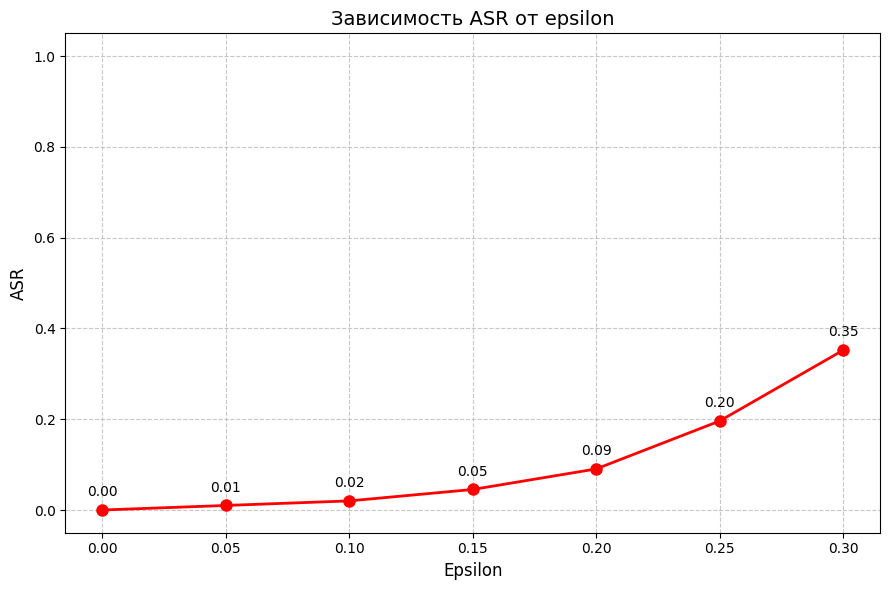

In [12]:
# TODO: выберите тестовый батч (например, 200 примеров) из test_loader
# TODO: для каждого epsilon постройте FGSM-атаку на substitute_model
# TODO: проверьте ASR на target_model ЧЕРЕЗ oracle.label (не напрямую!)
# TODO: постройте график ASR(epsilon)

test_images = test_dataset.data[:200].float().unsqueeze(1) / 255.0
test_labels = test_dataset.targets[:200]

oracle.reset()
clean_preds = oracle.label(test_images.to(device)).cpu()
clean_correct = clean_preds == test_labels

epsilons = [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3]
transfer_asr = []

for eps in epsilons:
    if eps == 0:
        transfer_asr.append(0.0)
        continue
    x_adv = fgsm_attack(substitute_model, test_images.to(device), test_labels.to(device), eps, crit)
    preds = oracle.label(x_adv).cpu()
    asr = ((preds != test_labels) & clean_correct).sum().item() / clean_correct.sum().item()
    transfer_asr.append(asr)
    print(f"eps={eps}, transfer ASR={asr:.4f}")

transfer_queries = oracle.n_queries

plt.figure(figsize=(9, 6))
plt.plot(epsilons, transfer_asr, marker='o', linestyle='-', color='red', linewidth=2, markersize=8)
plt.title('Зависимость ASR от epsilon', fontsize=14)
plt.xlabel('Epsilon', fontsize=12)
plt.ylabel('ASR', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(epsilons)
plt.ylim(-0.05, 1.05)

for i, txt in enumerate(transfer_asr):
    plt.annotate(f"{txt:.2f}", (epsilons[i], transfer_asr[i]),
                 textcoords="offset points", xytext=(0, 10), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

### 2.3. Сравнение с белоящичным эталоном

**Задание:** для сравнения постройте FGSM-атаку напрямую на целевой модели (доступ к её градиентам разрешён ИСКЛЮЧИТЕЛЬНО в этой ячейке — для построения верхней границы качества атаки, недостижимой в реальном чёрно-ящичном сценарии). Постройте оба графика ASR(epsilon) на одной оси.

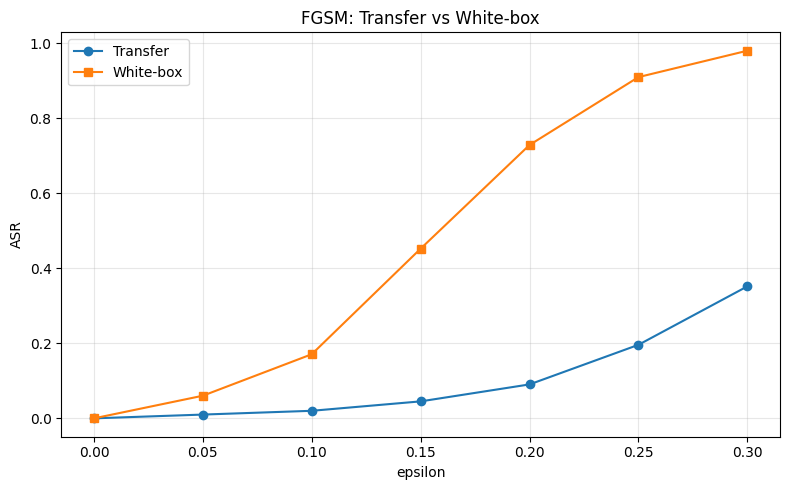

In [13]:
# TODO: постройте white-box FGSM атаку напрямую на target_model
# TODO: сравните на одном графике с transfer_asr
oracle.reset()
whitebox_asr = []

for eps in epsilons:
    if eps == 0:
        whitebox_asr.append(0.0)
        continue
    x_adv = fgsm_attack(target_model, test_images.to(device), test_labels.to(device), eps, crit)
    preds = oracle.label(x_adv).cpu()
    asr = ((preds != test_labels) & clean_correct).sum().item() / clean_correct.sum().item()
    whitebox_asr.append(asr)

plt.figure(figsize=(8, 5))
plt.plot(epsilons, transfer_asr, "o-", label="Transfer")
plt.plot(epsilons, whitebox_asr, "s-", label="White-box")
plt.xlabel("epsilon")
plt.ylabel("ASR")
plt.title("FGSM: Transfer vs White-box")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

**Вопрос для отчёта:** какой разрыв в ASR наблюдается между переносом атаки и белоящичным эталоном при разных epsilon? Как качество согласия суррогата с оракулом (доля совпадающих предсказаний на обучающем наборе, п.2.1) связано с этим разрывом?

_Ваш ответ:_

## Часть III. Score-based атаки

### 3.1. ZOO: оценка градиента через конечные разности

**Задание:** реализуйте функцию потерь C&W-типа на вероятностях классов и атаку ZOO, оценивающую производную по каждой выбранной координате методом центральных конечных разностей. Атака должна использовать ТОЛЬКО `oracle.probs(x)` — доступ к градиентам запрещён.

In [14]:
# TODO: реализуйте функцию потерь zoo_loss(probs, y_true, kappa=0.0)
# f(x) = max(log p_true - max_{i!=true} log p_i, -kappa)
def zoo_loss(probs, y_true, kappa=0.0):
    log_p = torch.log(probs + 1e-10)
    true_log = log_p.gather(1, y_true.view(-1, 1)).squeeze(1)
    mask = torch.ones_like(log_p)
    mask.scatter_(1, y_true.view(-1, 1), 0)
    other_log = log_p.masked_fill(mask == 0, -1e9).max(dim=1).values
    return torch.clamp(true_log - other_log, min=-kappa)


In [15]:
# TODO: реализуйте функцию zoo_attack(oracle, x, y_true, epsilon, alpha, num_iter, h, coord_batch)
# На каждой итерации:
# 1. случайно выберите coord_batch координат
# 2. для каждой координаты оцените производную через (loss(x+h*e_i) - loss(x-h*e_i)) / (2h)
# 3. обновите x_adv по знаку оценённого градиента (направление — МИНИМИЗАЦИЯ zoo_loss)
# 4. спроецируйте на epsilon-шар и диапазон [0, 1]

def zoo_attack(oracle, x, y_true, epsilon=0.3, alpha=0.02, num_iter=60, h=0.1, coord_batch=60):
    x_orig = x.clone()
    x_adv = x.clone()

    for _ in range(num_iter):
        coords = torch.randperm(784)[:coord_batch]
        grad_est = torch.zeros_like(x_adv)

        for c in coords:
            xp = x_adv.clone().view(-1)
            xm = x_adv.clone().view(-1)
            xp[c] = min(1.0, xp[c].item() + h)
            xm[c] = max(0.0, xm[c].item() - h)
            xp = xp.view(1, 1, 28, 28)
            xm = xm.view(1, 1, 28, 28)

            l_plus = zoo_loss(oracle.probs(xp), y_true).item()
            l_minus = zoo_loss(oracle.probs(xm), y_true).item()
            grad_est.view(-1)[c] = (l_plus - l_minus) / (2 * h)

        x_adv = x_adv - alpha * grad_est.sign()
        delta = torch.clamp(x_adv - x_orig, -epsilon, epsilon)
        x_adv = torch.clamp(x_orig + delta, 0, 1)

    return x_adv.detach()

### 3.2. Демонстрация ZOO-атаки

**Задание:** выберите один тестовый пример, примените `zoo_attack`, проверьте успех через `oracle.label`, посчитайте L2-норму возмущения и число потраченных запросов. Визуализируйте оригинал и adversarial-пример.

ZOO: success=True, L2=0.7397, queries=6001, time=2.06s


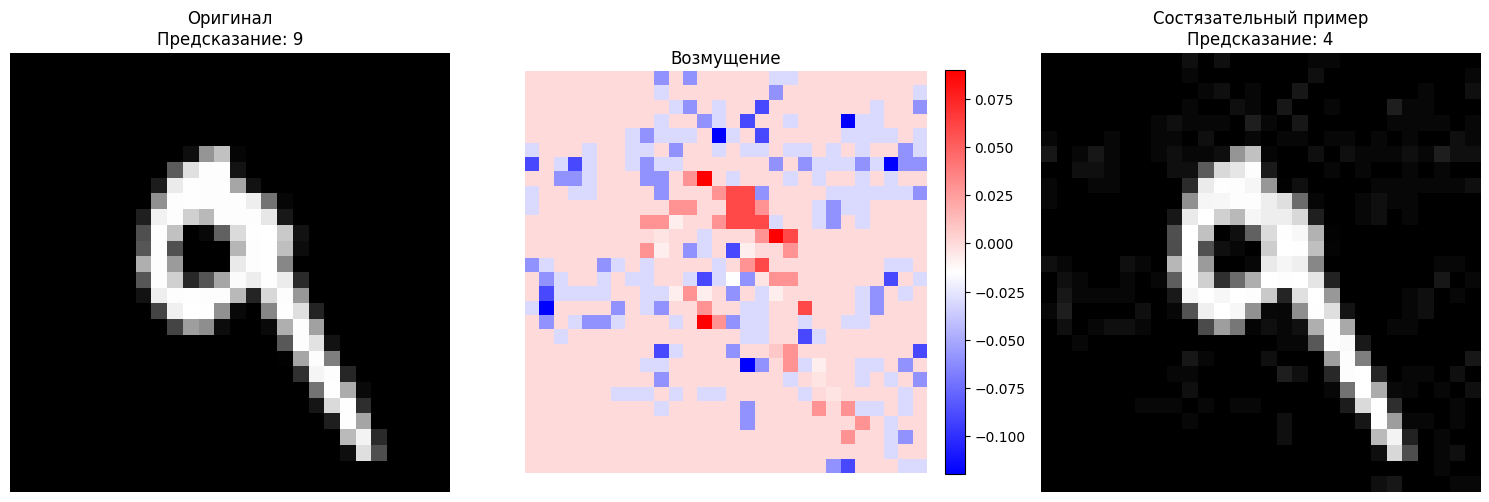

In [16]:
oracle.reset()

# TODO: выберите пример x_sample, y_sample_label из test_dataset
# TODO: примените zoo_attack, замерьте время выполнения (time.time())
# TODO: проверьте успех, L2-норму, число запросов oracle.n_queries
# TODO: визуализируйте оригинал и adversarial-пример
oracle.reset()
sample_idx = 7
x_sample = test_dataset.data[sample_idx].float().unsqueeze(0).unsqueeze(0) / 255.0
y_sample = torch.tensor([test_dataset.targets[sample_idx].item()])

pred_orig = oracle.label(x_sample).item()

t0 = time.time()
x_adv_zoo = zoo_attack(oracle, x_sample, y_sample, epsilon=0.4, alpha=0.03, num_iter=60, h=0.1, coord_batch=50)
t_zoo = time.time() - t0
zoo_queries = oracle.n_queries

pred_zoo = oracle.label(x_adv_zoo).item()
success_zoo = pred_zoo != y_sample.item()
l2_zoo = (x_adv_zoo - x_sample).norm().item()
print(f"ZOO: success={success_zoo}, L2={l2_zoo:.4f}, queries={zoo_queries}, time={t_zoo:.2f}s")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(x_sample.cpu().numpy()[0, 0], cmap='gray')
axes[0].set_title(f"Оригинал\nПредсказание: {pred_orig}")
axes[0].axis('off')

im = axes[1].imshow((x_sample-x_adv_zoo).cpu().numpy()[0, 0], cmap='bwr')
axes[1].set_title(f"Возмущение")
axes[1].axis('off')
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

axes[2].imshow(x_adv_zoo.cpu().numpy()[0, 0], cmap='gray')
axes[2].set_title(f"Состязательный пример\nПредсказание: {pred_zoo}")
axes[2].axis('off')

plt.tight_layout()
plt.show()

### 3.3. NES: оценка градиента через антитетическую случайную выборку

**Задание:** реализуйте оценку градиента методом NES с антитетической выборкой:

$ \hat{g} = \frac{1}{2\sigma P} \sum_{i=1}^{P} \left( L(x + \sigma u_i) - L(x - \sigma u_i) \right) u_i $

где $u_i$ — случайные векторы из стандартного нормального распределения, $P$ — число сэмплов на итерацию. Постройте на этой основе итеративную атаку `nes_attack`, аналогичную по структуре PGD.

In [17]:
# TODO: реализуйте nes_gradient_estimate(oracle, x, y_true, sigma, n_samples)
def nes_gradient_estimate(oracle, x, y_true, sigma=0.1, n_samples=15):
    grad = torch.zeros_like(x)
    for _ in range(n_samples):
        u = torch.randn_like(x)
        l_plus = zoo_loss(oracle.probs(torch.clamp(x + sigma * u, 0, 1)), y_true).item()
        l_minus = zoo_loss(oracle.probs(torch.clamp(x - sigma * u, 0, 1)), y_true).item()
        grad += (l_plus - l_minus) * u
    return grad / (2 * sigma * n_samples)


In [18]:
# TODO: реализуйте nes_attack(oracle, x, y_true, epsilon, alpha, num_iter, sigma, n_samples)
# по аналогии с zoo_attack, но с использованием nes_gradient_estimate
def nes_attack(oracle, x, y_true, epsilon=0.3, alpha=0.05, num_iter=15, sigma=0.1, n_samples=15):
    x_orig = x.clone()
    x_adv = x.clone()
    for _ in range(num_iter):
        grad = nes_gradient_estimate(oracle, x_adv, y_true, sigma, n_samples)
        x_adv = x_adv - alpha * grad.sign()
        delta = torch.clamp(x_adv - x_orig, -epsilon, epsilon)
        x_adv = torch.clamp(x_orig + delta, 0, 1)
    return x_adv.detach()


NES: success=True, L2=1.7938, queries=450, time=0.17s


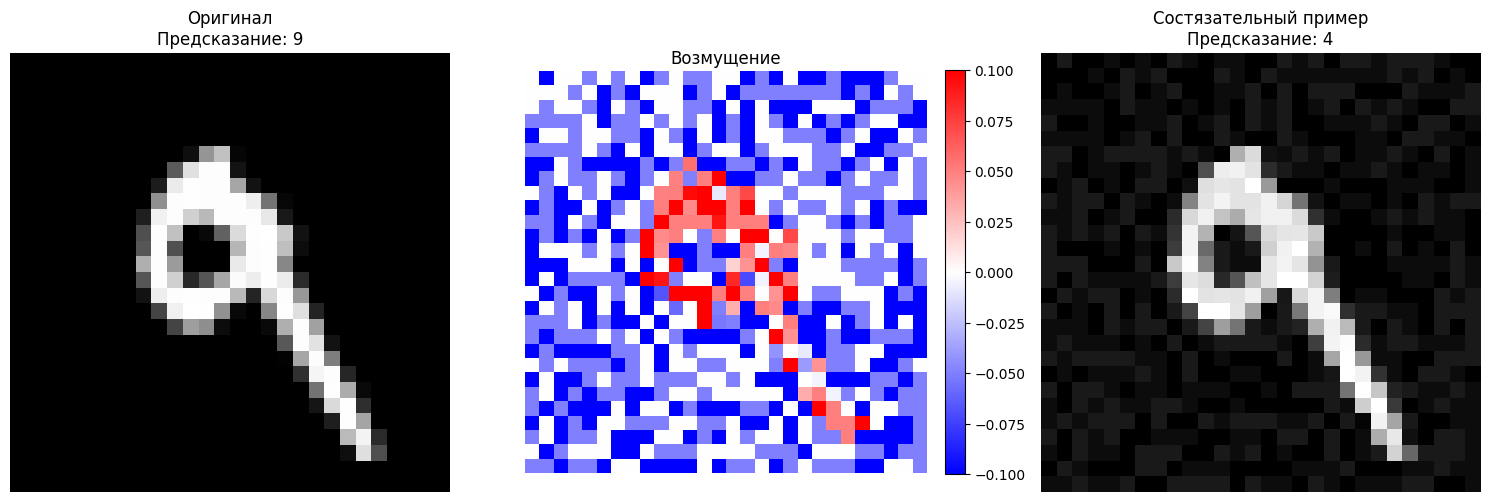

In [19]:
# TODO: примените nes_attack к тому же примеру, что и в п.3.2
# TODO: проверьте успех, L2-норму, число запросов, время выполнения
oracle.reset()
t0 = time.time()
x_adv_nes = nes_attack(oracle, x_sample, y_sample, epsilon=0.1, alpha=0.05, num_iter=15, sigma=0.1, n_samples=15)
t_nes = time.time() - t0
nes_queries = oracle.n_queries

pred_nes = oracle.label(x_adv_nes).item()
success_nes = pred_nes != y_sample.item()
l2_nes = (x_adv_nes - x_sample).norm().item()
print(f"NES: success={success_nes}, L2={l2_nes:.4f}, queries={nes_queries}, time={t_nes:.2f}s")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(x_sample.cpu().numpy()[0, 0], cmap='gray')
axes[0].set_title(f"Оригинал\nПредсказание: {pred_orig}")
axes[0].axis('off')

im = axes[1].imshow((x_sample-x_adv_nes).cpu().numpy()[0, 0], cmap='bwr')
axes[1].set_title(f"Возмущение")
axes[1].axis('off')
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

axes[2].imshow(x_adv_nes.cpu().numpy()[0, 0], cmap='gray')
axes[2].set_title(f"Состязательный пример\nПредсказание: {pred_nes}")
axes[2].axis('off')

plt.tight_layout()
plt.show()

### 3.4. Сравнение ZOO и NES

**Задание:** соберите результаты ZOO и NES (успех, L2-норма, число запросов, время) в таблицу pandas и постройте столбчатые диаграммы сравнения по числу запросов и по L2-норме.

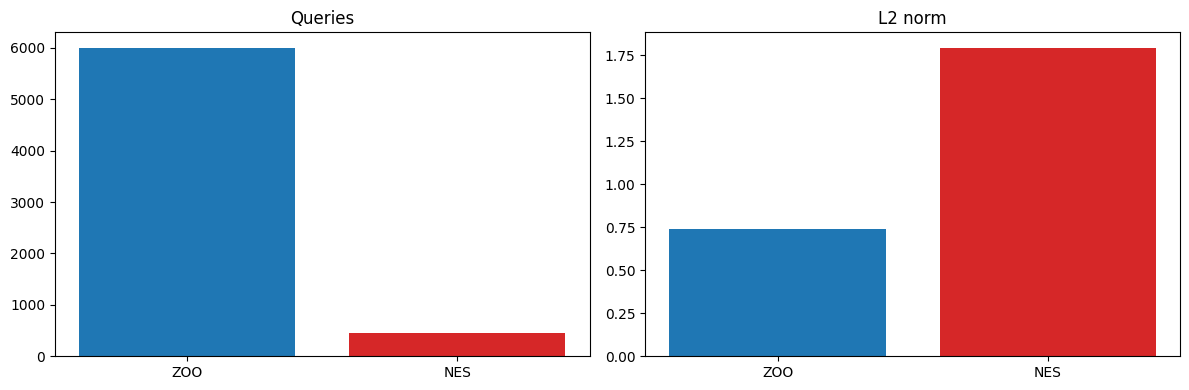

In [20]:
# TODO: постройте сравнительную таблицу и графики для ZOO и NES
cmp_df = pd.DataFrame([
    {"method": "ZOO", "success": success_zoo, "L2": l2_zoo, "queries": zoo_queries, "time_s": t_zoo},
    {"method": "NES", "success": success_nes, "L2": l2_nes, "queries": nes_queries, "time_s": t_nes},
])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(cmp_df["method"], cmp_df["queries"], color=["#1f77b4", "#d62728"])
axes[0].set_title("Queries")
axes[1].bar(cmp_df["method"], cmp_df["L2"], color=["#1f77b4", "#d62728"])
axes[1].set_title("L2 norm")
plt.tight_layout()
plt.show()

**Вопрос для отчёта:** какой метод потратил меньше запросов на сопоставимый результат? Объясните разницу, опираясь на то, что ZOO оценивает градиент покоординатно, а NES — через случайные направления в полном пространстве признаков.

_Ваш ответ:_

## Часть IV. Decision-based атака: Boundary Attack

### 4.1. Реализация упрощённой Boundary Attack

**Задание:** реализуйте функцию `is_adversarial`, которая через `oracle.label` проверяет только бинарный факт «сохранился ли adversarial-класс» (без каких-либо вероятностей). На основе неё реализуйте `boundary_attack`:

1. Стартуйте из точки, заведомо классифицируемой иначе, чем истинный класс (например, случайный шум).
2. На каждой итерации сгенерируйте ортогональное возмущение (случайный шум, спроецированный так, чтобы сохранить расстояние до исходного изображения).
3. Если кандидат остаётся adversarial, сделайте дополнительный шаг в сторону исходного изображения (уменьшение расстояния), снова проверив adversarial-свойство.
4. Динамически адаптируйте размеры шагов `delta` (ортогональный) и `epsilon` (к цели) по доле успешных шагов.

In [21]:
# TODO: реализуйте is_adversarial(oracle, x, true_label)
def is_adversarial(oracle, x, true_label):
    return oracle.label(x).item() != true_label


In [22]:
# TODO: реализуйте boundary_attack(oracle, x_orig, true_label, x_init, num_steps, init_delta, init_epsilon)
# Возвращает: финальный x_adv и историю L2-нормы возмущения по итерациям (для графика сходимости)
def boundary_attack(oracle, x_orig, true_label, x_init, num_steps=200, init_delta=0.1, init_epsilon=0.1):
    # TODO:
    # 1. инициализация x_adv = x_init, delta, epsilon
    # 2. цикл num_steps раз:
    #    - вычислите текущее направление diff = x_adv - x_orig
    #    - сгенерируйте случайный шум, ортогонализируйте его относительно diff
    #    - масштабируйте по delta * ||diff||, получите x_candidate
    #    - если is_adversarial(x_candidate): попробуйте шаг к цели (уменьшение расстояния)
    #      - если шаг к цели тоже adversarial: примите оба шага, увеличьте delta и epsilon
    #      - иначе: примите только ортогональный шаг, увеличьте delta
    #    - иначе: уменьшите delta и epsilon
    #    - сохраните текущую L2-норму в историю
    x_adv = x_init.clone()
    delta = init_delta
    eps_step = init_epsilon
    history = []

    for _ in range(num_steps):
        diff = x_adv - x_orig
        d_norm = diff.norm() + 1e-10

        noise = torch.randn_like(x_adv)
        noise = noise - (noise * diff).sum() / (d_norm ** 2) * diff
        noise = noise / (noise.norm() + 1e-10)

        x_cand = x_adv + delta * d_norm * noise
        x_cand = torch.clamp(x_cand, 0, 1)

        if is_adversarial(oracle, x_cand, true_label):
            x_adv = x_cand
            x_t = x_adv + eps_step * (x_orig - x_adv)
            x_t = torch.clamp(x_t, 0, 1)
            if is_adversarial(oracle, x_t, true_label):
                x_adv = x_t
                delta = min(delta * 1.2, 0.5)
                eps_step = min(eps_step * 1.2, 0.5)
            else:
                delta = min(delta * 1.1, 0.5)
        else:
            delta = max(delta * 0.9, 0.01)
            eps_step = max(eps_step * 0.9, 0.01)

        history.append((x_adv - x_orig).norm().item())

    return x_adv.detach(), history

### 4.2. Демонстрация атаки

**Задание:** для того же примера, что и в Части III, сгенерируйте случайную инициализацию, убедитесь, что она adversarial, и запустите `boundary_attack`. Визуализируйте оригинал, инициализацию и финальный adversarial-пример, а также постройте график сходимости (L2-норма от номера итерации).

In [23]:
# TODO: сгенерируйте x_init (случайный шум), проверьте is_adversarial
# TODO: запустите boundary_attack, замерьте время
# TODO: проверьте финальный успех, L2-норму, число запросов
oracle.reset()
x_init = None
for _ in range(200):
    cand = torch.rand_like(x_sample)
    if is_adversarial(oracle, cand, y_sample.item()):
        x_init = cand
        break
print(f"Initialized adversarial at attempt {_ + 1}")

t0 = time.time()
x_adv_ba, ba_history = boundary_attack(oracle, x_sample, y_sample.item(), x_init, num_steps=200)
t_ba = time.time() - t0
ba_queries = oracle.n_queries

pred_ba = oracle.label(x_adv_ba).item()
success_ba = pred_ba != y_sample.item()
l2_ba = (x_adv_ba - x_sample).norm().item()
print(f"BA: success={success_ba}, L2={l2_ba:.4f}, queries={ba_queries}, time={t_ba:.2f}s")

Initialized adversarial at attempt 1
BA: success=True, L2=6.4977, queries=391, time=0.14s


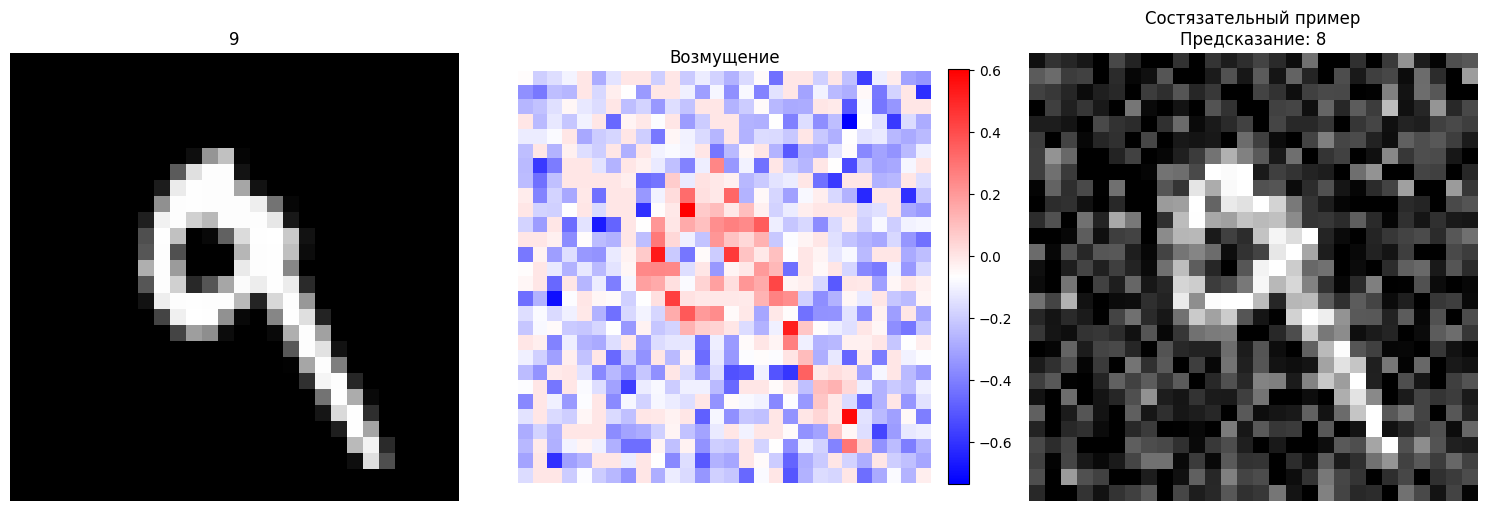

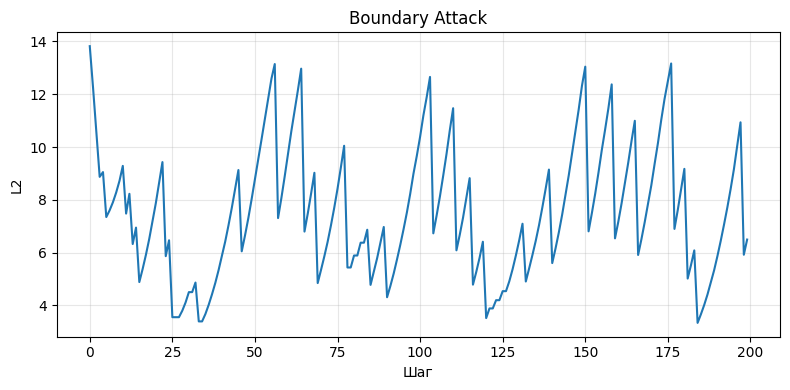

In [24]:
# TODO: визуализируйте оригинал / инициализацию / финальный adversarial-пример (3 подграфика)
# TODO: постройте график сходимости L2-нормы по итерациям
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(x_sample.cpu().numpy()[0, 0], cmap='gray')
axes[0].set_title(f"{pred_orig}")
axes[0].axis('off')

im = axes[1].imshow((x_sample-x_adv_ba).cpu().numpy()[0, 0], cmap='bwr')
axes[1].set_title(f"Возмущение")
axes[1].axis('off')
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

axes[2].imshow(x_adv_ba.cpu().numpy()[0, 0], cmap='gray')
axes[2].set_title(f"Состязательный пример\nПредсказание: {pred_ba}")
axes[2].axis('off')

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(ba_history)
plt.xlabel("Шаг")
plt.ylabel("L2")
plt.title("Boundary Attack")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Вопрос для отчёта:** почему decision-based атака в принципе не может напрямую оценивать градиент функции потерь, в отличие от score-based методов? Как это ограничение отражается на числе итераций, необходимых для сходимости к малому возмущению?

_Ваш ответ:_

## Часть V. Итоговое сравнение четырёх методов

**Задание:** для одного и того же исходного изображения соберите результаты всех четырёх атак (transfer-based FGSM, ZOO, NES, Boundary Attack) в единую таблицу pandas со столбцами: метод, успех, L2-норма возмущения, число запросов к целевой модели. Сохраните таблицу в CSV. Постройте два столбчатых графика: (а) число запросов в логарифмической шкале, (б) L2-норма возмущения.

In [25]:
# TODO: соберите итоговую таблицу сравнения (используйте результаты предыдущих частей;
# для transfer-based учтите, что запросов к целевой модели требуется всего 1 — финальная проверка)
oracle.reset()
x_adv_transfer = fgsm_attack(substitute_model, x_sample, y_sample, 0.3, crit)
pred_transfer = oracle.label(x_adv_transfer).item()
transfer_single_queries = oracle.n_queries
success_transfer = pred_transfer != y_sample.item()
l2_transfer = (x_adv_transfer - x_sample).norm().item()
print(f"Transfer: success={success_transfer}, L2={l2_transfer:.4f}, queries={transfer_single_queries}")
# TODO: summary = pd.DataFrame([...])
# TODO: summary.to_csv("lab6_summary.csv", index=False)
summary = pd.DataFrame([
    {"method": "Transfer FGSM", "success": success_transfer, "L2": l2_transfer, "queries": transfer_single_queries},
    {"method": "ZOO", "success": success_zoo, "L2": l2_zoo, "queries": zoo_queries},
    {"method": "NES", "success": success_nes, "L2": l2_nes, "queries": nes_queries},
    {"method": "Boundary", "success": success_ba, "L2": l2_ba, "queries": ba_queries},
])
summary.to_csv("lab6_summary.csv", index=False)
print(summary)

Transfer: success=True, L2=6.3320, queries=1
          method  success        L2  queries
0  Transfer FGSM     True  6.332017        1
1            ZOO     True  0.739662     6001
2            NES     True  1.793825      450
3       Boundary     True  6.497677      391


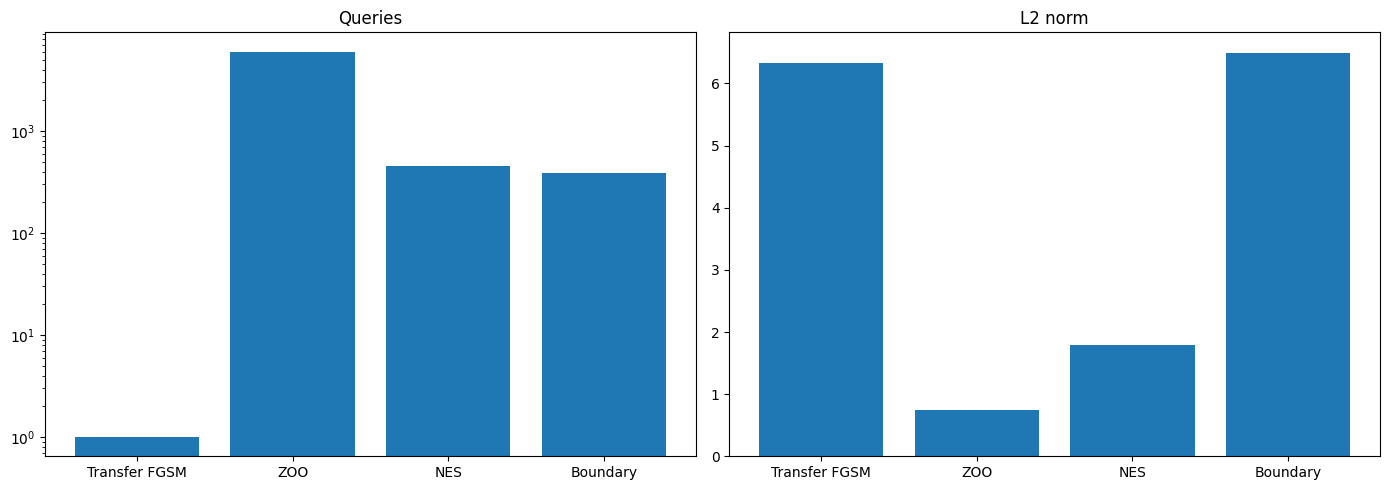

In [26]:
# TODO: постройте два столбчатых графика сравнения (число запросов — log-масштаб, L2-норма)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(summary["method"], summary["queries"])
axes[0].set_yscale("log")
axes[0].set_title("Queries")
axes[1].bar(summary["method"], summary["L2"])
axes[1].set_title("L2 norm")
plt.tight_layout()
plt.show()

**Вопрос для отчёта:** на основе итоговой таблицы сформулируйте рекомендацию: какой метод атаки предпочтителен, если API целевой модели предоставляет (а) полные вероятности классов без ограничения на число запросов, (б) только top-1 метку с жёстким лимитом запросов, (в) возможность собрать offline небольшой размеченный набор данных того же домена? Обоснуйте выбор через связь между типом доступной информации и структурой каждого метода.

_Ваш ответ:_  
а) Zoo атака
б) Transfer FGSM или Boundary
в) Transfer FGSM

## Часть VI. Итоговый вывод

**Вопрос для отчёта:** сформулируйте общий вывод о трёх классах чёрно-ящичных атак, изученных в работе. Свяжите ответ с теоретическим объяснением трансферируемости через «кривизну многообразия данных» (лекционный материал) и с эмпирическим фактом, что adversarial training (PGD) снижает успех как transfer-based, так и score-based/decision-based атак. Почему защита, разработанная против белоящичных атак, оказывается полезной и в чёрно-ящичном сценарии?

_Ваш ответ:_

---
Выполните **не менее двух** из следующих заданий. Оформите результаты в отдельных ячейках ниже.

### С1. Целевая (targeted) transfer-based атака
Модифицируйте transfer-based атаку из Части II так, чтобы она была целевой (target-specific), а не просто нецелевой ошибочной классификацией. Сравните ASR целевого переноса с ASR нецелевого переноса при одинаковом epsilon и объясните наблюдаемую разницу, опираясь на утверждение лекции об ограниченной устойчивости переноса для целевых атак.

### С2. Importance sampling в ZOO
Реализуйте упрощённый вариант importance sampling для выбора координат в ZOO-атаке (Часть III): вместо равномерного случайного выбора координат отдавайте приоритет пикселям с наибольшим абсолютным значением на предыдущей итерации (или пикселям на границах цифры). Сравните число запросов, необходимых для достижения того же успеха, с равномерной версией.

### С3. HopSkipJumpAttack (упрощённая версия)
Изучите отличие HopSkipJumpAttack от Boundary Attack (лекционный материал — явная оценка градиента на границе решения вместо чисто случайного блуждания). Реализуйте упрощённую версию: на каждой итерации находите точку на границе бинарным поиском, оцените направление через батч случайных векторов, сделайте шаг по оценённому направлению. Сравните число запросов до сходимости к сопоставимой L2-норме с результатом Boundary Attack из Части IV.

### С4. Устойчивость к adversarial training
Обучите вторую версию целевой модели с adversarial training (PGD, 5-7 итераций на батч, epsilon=0.15) — аналогично лабораторной работе по PGD/C&W/JSMA. Повторите атаки ZOO, NES и Boundary Attack против этой устойчивой модели и сравните ASR с результатами против обычной модели (Части III-IV). Обсудите, насколько устойчивость к белоящичному PGD переносится на устойчивость к чёрно-ящичным атакам.


In [27]:
# TODO: реализуйте выбранные задания (С1-С4) здесь
# Задание С1
def targeted_fgsm(model, x, y_target, epsilon, criterion):
    x = x.clone().detach().requires_grad_(True)
    loss = criterion(model(x), y_target)
    grad = torch.autograd.grad(loss, x)[0]
    return torch.clamp(x - epsilon * grad.sign(), 0, 1).detach()

oracle.reset()
eps_t = 0.3

x_adv_unt = fgsm_attack(substitute_model, test_images.to(device), test_labels.to(device), eps_t, crit)
preds_unt = oracle.label(x_adv_unt).cpu()
asr_unt = ((preds_unt != test_labels) & clean_correct).sum().item() / clean_correct.sum().item()

y_target = (test_labels + 1) % 10
x_adv_t = targeted_fgsm(substitute_model, test_images.to(device), y_target.to(device), eps_t, crit)
preds_t = oracle.label(x_adv_t).cpu()
asr_t = ((preds_t == y_target) & clean_correct).sum().item() / clean_correct.sum().item()

print(f"Untargeted ASR eps={eps_t}: {asr_unt:.4f}")
print(f"Targeted   ASR eps={eps_t}: {asr_t:.4f}")
print(f"Ratio: {asr_t / max(asr_unt, 1e-6):.4f}")

Untargeted ASR eps=0.3: 0.3518
Targeted   ASR eps=0.3: 0.0854
Ratio: 0.2429


HSJ: success=True, L2=10.5450, queries=231, time=0.08s
     method         L2  queries    time_s
0  Boundary   6.497677      391  0.143240
1       HSJ  10.544999      231  0.075297


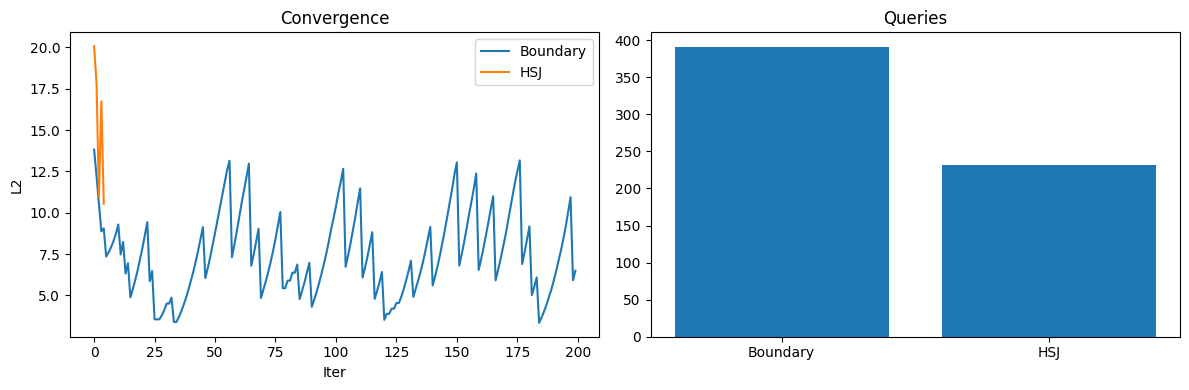

In [28]:
# Задание С3
def find_boundary(oracle, x_orig, x_adv, true_label, n_steps=15):
    x_low = x_orig.clone()
    x_high = x_adv.clone()
    for _ in range(n_steps):
        mid = (x_low + x_high) / 2
        if is_adversarial(oracle, mid, true_label):
            x_high = mid
        else:
            x_low = mid
    return x_high.detach()

def hsj_attack(oracle, x_orig, true_label, x_init, num_iter=5, n_samples=15, sigma=0.05, alpha=0.5):
    x_adv = x_init.clone()
    history = []

    for _ in range(num_iter):
        x_boundary = find_boundary(oracle, x_orig, x_adv, true_label, n_steps=15)

        grad_est = torch.zeros_like(x_boundary)
        for _ in range(n_samples):
            u = torch.randn_like(x_boundary)
            u = u / (u.norm() + 1e-10)
            b_plus = is_adversarial(oracle, torch.clamp(x_boundary + sigma * u, 0, 1), true_label)
            b_minus = is_adversarial(oracle, torch.clamp(x_boundary - sigma * u, 0, 1), true_label)
            grad_est += (int(b_plus) - int(b_minus)) * u
        grad_est = grad_est / (2 * sigma * n_samples)

        if grad_est.norm() < 1e-10:
            break

        diff = x_boundary - x_orig
        d_norm = diff.norm().item() + 1e-10
        step = alpha * d_norm

        x_new = x_boundary + step * (x_orig - x_boundary) / d_norm
        x_new = x_new + step * 0.3 * grad_est.sign()
        x_new = torch.clamp(x_new, 0, 1)

        if not is_adversarial(oracle, x_new, true_label):
            x_new = find_boundary(oracle, x_orig, x_new, true_label, n_steps=8)

        x_adv = x_new
        history.append((x_adv - x_orig).norm().item())

    return x_adv.detach(), history

oracle.reset()
x_init_hsj = None
for _ in range(200):
    cand = torch.rand_like(x_sample)
    if is_adversarial(oracle, cand, y_sample.item()):
        x_init_hsj = cand
        break

t0 = time.time()
x_adv_hsj, hsj_history = hsj_attack(oracle, x_sample, y_sample.item(), x_init_hsj)
t_hsj = time.time() - t0
hsj_queries = oracle.n_queries

pred_hsj = oracle.label(x_adv_hsj).item()
success_hsj = pred_hsj != y_sample.item()
l2_hsj = (x_adv_hsj - x_sample).norm().item()
print(f"HSJ: success={success_hsj}, L2={l2_hsj:.4f}, queries={hsj_queries}, time={t_hsj:.2f}s")

cmp = pd.DataFrame([
    {"method": "Boundary", "L2": l2_ba, "queries": ba_queries, "time_s": t_ba},
    {"method": "HSJ", "L2": l2_hsj, "queries": hsj_queries, "time_s": t_hsj},
])
print(cmp)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(ba_history, label="Boundary")
axes[0].plot(hsj_history, label="HSJ")
axes[0].set_xlabel("Iter")
axes[0].set_ylabel("L2")
axes[0].set_title("Convergence")
axes[0].legend()
axes[1].bar(cmp["method"], cmp["queries"])
axes[1].set_title("Queries")
plt.tight_layout()
plt.show()

---


## Требования к сдаче
- Ноутбук выполняется целиком без ошибок (Kernel → Restart & Run All).
- Все `# TODO` заполнены, все вопросы для отчёта содержат письменный ответ.
- Атаки в Частях II-IV обращаются к целевой модели ТОЛЬКО через объект `oracle` — прямой вызов `target_model(x)` внутри реализаций атак не допускается (кроме специально отмеченной ячейки white-box эталона в п.2.3).
- Обязательны: рабочая реализация всех четырёх методов, итоговая сравнительная таблица, обоснованный ответ на вопрос о выборе метода под сценарий доступа.
